In [452]:
import pandas as pd
import numpy as np

In [329]:
df = pd.read_csv('../data/student_data.csv')

In [330]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [331]:
df.shape

(6607, 20)

In [332]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [333]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [334]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


Hours_Studied
[23 19 24 29 25 17 21  9 10 14 22 15 12 20 11 13 16 18 31  8 26 28  4 35
 27 33 36 43 34  1 30  7 32  6 38  5  3  2 39 37 44]

Attendance
[ 84  64  98  89  92  88  78  94  80  97  83  82  68  60  70  75  99  74
  65  62  91  90  66  69  72  63  61  86  77  71  67  87  73  96 100  81
  95  79  85  76  93]

Parental_Involvement
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Access_to_Resources
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Extracurricular_Activities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Sleep_Hours
[ 7  8  6 10  9  5  4]

Previous_Scores
[ 73  59  91  98  65  89  68  50  80  71  88  87  97  72  74  70  82  58
  99  84 100  75  54  90  94  51  57  66  96  93  56  52  63  79  81  69
  95  60  92  77  62  85  78  64  76  55  86  61  53  83  67]

Motivation_Level
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Internet_Access
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Tutoring_Sessions
[0 2 1 

In [335]:
df[df["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [336]:
df["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [337]:
X = df[df["Exam_Score"] <= 100]

In [338]:
df["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [339]:
print(df["Teacher_Quality"].value_counts())
print()
print(df["Parental_Education_Level"].value_counts())
print()
print(df["Distance_from_Home"].value_counts())

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64


In [340]:
df.corr(numeric_only=True)["Exam_Score"].sort_values()


Sleep_Hours         -0.017022
Physical_Activity    0.027824
Tutoring_Sessions    0.156525
Previous_Scores      0.175079
Hours_Studied        0.445455
Attendance           0.581072
Exam_Score           1.000000
Name: Exam_Score, dtype: float64

In [341]:
df.groupby("Parental_Involvement")["Exam_Score"].mean()

Parental_Involvement
High      68.092767
Low       66.358265
Medium    67.098156
Name: Exam_Score, dtype: float64

In [342]:
df.groupby("Motivation_Level")["Exam_Score"].mean()



Motivation_Level
High      67.704321
Low       66.752194
Medium    67.330648
Name: Exam_Score, dtype: float64

In [343]:
df.groupby("Access_to_Resources")["Exam_Score"].mean()


Access_to_Resources
High      68.092152
Low       66.203351
Medium    67.134378
Name: Exam_Score, dtype: float64

In [344]:

df.groupby("Teacher_Quality")["Exam_Score"].mean()

Teacher_Quality
High      67.676939
Low       66.753425
Medium    67.109299
Name: Exam_Score, dtype: float64

In [345]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

In [346]:
from sklearn.model_selection import train_test_split

In [347]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [348]:
X_train.shape

(5285, 19)

In [349]:
X_test.shape

(1322, 19)

In [350]:
y_train.shape

(5285,)

In [351]:
y_test.shape

(1322,)

In [352]:
X_train

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
5810,27,79,Low,High,Yes,8,63,High,Yes,2,Low,Medium,Public,Negative,5,No,College,Moderate,Female
1268,16,86,High,Medium,Yes,7,94,Medium,Yes,2,Low,High,Public,Neutral,3,No,High School,Moderate,Female
414,22,87,Low,Medium,No,8,83,Low,Yes,1,Low,Medium,Public,Neutral,1,No,College,Far,Male
4745,18,100,High,Medium,Yes,10,86,Medium,Yes,1,Medium,Medium,Public,Neutral,3,No,High School,Near,Male
654,35,78,High,Low,Yes,10,99,Medium,Yes,1,Low,Medium,Private,Positive,2,No,High School,Near,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,15,82,Medium,Medium,Yes,7,93,Medium,Yes,3,Low,High,Public,Negative,2,No,High School,Moderate,Female
5191,20,65,Medium,Medium,Yes,8,97,High,Yes,0,Low,Medium,Public,Negative,3,No,College,Near,Female
5226,17,64,High,Low,Yes,10,63,Medium,Yes,0,High,Medium,Public,Positive,3,No,High School,Moderate,Female
5390,16,100,High,High,Yes,7,82,Medium,Yes,2,High,Medium,Public,Positive,2,No,High School,Near,Male


In [353]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include="str").columns.tolist()

In [354]:
print(numeric_features)
print(categorical_features)

['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [355]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [356]:
numeric_transformer = StandardScaler()

In [357]:
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

In [358]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [359]:
from sklearn.pipeline import Pipeline

In [360]:
from sklearn.linear_model import LinearRegression

In [361]:
model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ])

In [362]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [363]:
y_pred = model.predict(X_test)

In [364]:
print(y_pred[:10])

[64.53058853 65.26137437 71.53637796 64.26899154 66.5249958  66.61805289
 72.46024813 66.49691191 69.98618172 70.13544347]


In [365]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [366]:
mse = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 0.4499495002270691
Root Mean Squared Error: 1.803352774026728
R-squared: 0.7699282240123635


In [367]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [368]:
results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

In [369]:
results.sort_values("Absolute_Error", ascending=False).head(10)

,Actual,Predicted,Error,Absolute_Error
217,89,60.985837,28.014163,28.014163
4192,98,70.905015,27.094985,27.094985
2687,87,60.120182,26.879818,26.879818
4531,93,67.565283,25.434717,25.434717
5966,97,73.036013,23.963987,23.963987
2513,88,68.018199,19.981801,19.981801
5989,80,64.933298,15.066702,15.066702
5725,65,66.130694,-1.130694,1.130694
3543,57,58.119154,-1.119154,1.119154
3686,67,68.094804,-1.094804,1.094804


In [370]:
worst_predictions = results.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

In [371]:
X_test.loc[worst_predictions.index]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,Medium,Medium,Public,Positive,2,No,College,Moderate,Female
2687,11,71,Low,Medium,Yes,8,55,Medium,Yes,1,Low,Medium,Public,Negative,3,No,College,Near,Female
4531,26,69,High,High,No,7,95,Low,No,0,Medium,Medium,Public,Negative,3,No,Postgraduate,Near,Female
5966,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,High,High,Public,Neutral,3,No,High School,Near,Male
2513,18,86,High,Medium,No,8,60,Medium,Yes,2,Low,High,Private,Neutral,1,No,College,Near,Male
5989,18,61,Medium,Low,Yes,6,91,High,Yes,3,Medium,High,Public,Positive,3,No,College,Moderate,Female
5725,13,73,Medium,High,No,8,93,Medium,Yes,0,High,High,Public,Neutral,3,No,Postgraduate,NaN,Female
3543,14,67,Low,Low,Yes,7,66,Low,Yes,0,Low,Medium,Public,Neutral,4,No,High School,Far,Female
3686,35,68,Low,High,Yes,5,64,Medium,Yes,0,High,Low,Public,Positive,4,Yes,High School,Near,Male


In [372]:
worst_students = X_test.loc[worst_predictions.index].copy()

worst_students["Actual"] = y_test.loc[worst_predictions.index]
worst_students["Predicted"] = results.loc[worst_predictions.index, "Predicted"]
worst_students["Error"] = results.loc[worst_predictions.index, "Error"]

In [373]:
worst_students

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Actual,Predicted,Error
217,19,70,Medium,Low,No,7,54,High,Yes,0,...,Public,Positive,2,Yes,High School,Moderate,Male,89,60.985837,28.014163
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,...,Public,Positive,2,No,College,Moderate,Female,98,70.905015,27.094985
2687,11,71,Low,Medium,Yes,8,55,Medium,Yes,1,...,Public,Negative,3,No,College,Near,Female,87,60.120182,26.879818
4531,26,69,High,High,No,7,95,Low,No,0,...,Public,Negative,3,No,Postgraduate,Near,Female,93,67.565283,25.434717
5966,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,...,Public,Neutral,3,No,High School,Near,Male,97,73.036013,23.963987
2513,18,86,High,Medium,No,8,60,Medium,Yes,2,...,Private,Neutral,1,No,College,Near,Male,88,68.018199,19.981801
5989,18,61,Medium,Low,Yes,6,91,High,Yes,3,...,Public,Positive,3,No,College,Moderate,Female,80,64.933298,15.066702
5725,13,73,Medium,High,No,8,93,Medium,Yes,0,...,Public,Neutral,3,No,Postgraduate,NaN,Female,65,66.130694,-1.130694
3543,14,67,Low,Low,Yes,7,66,Low,Yes,0,...,Public,Neutral,4,No,High School,Far,Female,57,58.119154,-1.119154
3686,35,68,Low,High,Yes,5,64,Medium,Yes,0,...,Public,Positive,4,Yes,High School,Near,Male,67,68.094804,-1.094804


In [374]:
df["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [375]:
df["Exam_Score"].value_counts().sort_index()


Exam_Score
55       1
56       1
57       4
58      22
59      40
60      77
61     171
62     264
63     371
64     501
65     679
66     751
67     717
68     759
69     624
70     542
71     408
72     304
73     141
74     106
75      48
76      16
77       5
78       4
79       3
80       5
82       4
83       1
84       3
85       1
86       4
87       2
88       3
89       3
91       1
92       2
93       2
94       4
95       2
96       1
97       3
98       3
99       2
100      1
101      1
Name: count, dtype: int64

In [376]:
results.describe()

,Actual,Predicted,Error,Absolute_Error
count,1322.000000,1322.000000,1322.000000,1322.000000
mean,67.317700,67.366130,-0.048429,0.449950
std,3.761087,3.317961,1.803385,1.746979
min,55.000000,55.389640,-1.130694,0.000235
25%,65.000000,65.054047,-0.442320,0.131562
50%,67.000000,67.275719,-0.180970,0.287562
75%,70.000000,69.727215,0.094511,0.477946
max,98.000000,76.525885,28.014163,28.014163


In [377]:
results[["Actual", "Predicted"]].corr()

,Actual,Predicted
Actual,1.000000,0.877562
Predicted,0.877562,1.000000


In [378]:
print("Actual mean:", y_test.mean())
print("Predicted mean:", y_pred.mean())

Actual mean: 67.3177004538578
Predicted mean: 67.36612989754012


In [379]:
print("Actual range:", y_test.min(), "to", y_test.max())
print("Predicted range:", y_pred.min(), "to", y_pred.max())

Actual range: 55 to 98
Predicted range: 55.38963998215765 to 76.52588468067859


**Baseline - Linear Regression**: MAE 0.415, RMSE 1.521, R^2 0.825. Predictions were highly correlated with actual scores (r = 0.909...), but the model compressed predictions towards the mean, with a predicted range of 55.5-78.2 compared with an actual range of 55-98. The largest errors occured on unusually high scoring students.

In [380]:
from sklearn.tree import DecisionTreeRegressor

In [381]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42)),
])

In [382]:
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [383]:
tree_pred = tree_model.predict(X_test)

In [384]:
tree_mse = mean_absolute_error(y_test, tree_pred)
tree_rmse = mean_squared_error(y_test, tree_pred) ** 0.5
tree_r2 = r2_score(y_test, tree_pred)

print(f"Mean Absolute Error: {tree_mse}")
print(f"Root Mean Squared Error: {tree_rmse}")
print(f"R-squared: {tree_r2}")

Mean Absolute Error: 1.6391830559757943
Root Mean Squared Error: 3.146811175600871
R-squared: 0.29944323994358724


In [385]:
tree_train_pred = tree_model.predict(X_train)

tree_train_mae = mean_absolute_error(y_train, tree_train_pred)
tree_train_rmse = mean_squared_error(y_train, tree_train_pred) ** 0.5
tree_train_r2 = r2_score(y_train, tree_train_pred)

print("Training MAE:", tree_train_mae)
print("Training RMSE:", tree_train_rmse)
print("Training R²:", tree_train_r2)

Training MAE: 0.0
Training RMSE: 0.0
Training R²: 1.0


In [386]:
controlled_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=5, random_state=42)),
])

In [387]:
controlled_tree.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [388]:
controlled_tree_pred = controlled_tree.predict(X_test)

In [389]:
controlled_tree_mse = mean_absolute_error(y_test, controlled_tree_pred)
controlled_tree_rmse = mean_squared_error(y_test, controlled_tree_pred) ** 0.5
controlled_tree_r2 = r2_score(y_test, controlled_tree_pred)

print(f"Mean Absolute Error: {controlled_tree_mse}")
print(f"Root Mean Squared Error: {controlled_tree_rmse}")
print(f"R-squared: {controlled_tree_r2}")

Mean Absolute Error: 1.5917356707973453
Root Mean Squared Error: 2.537772021720446
R-squared: 0.5443753934404274


In [390]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20]

tree_results = []

for depth in depths:

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", DecisionTreeRegressor(
            max_depth=depth,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    tree_results.append({
        "Depth": depth,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": r2_score(y_test, predictions)
    })

tree_results = pd.DataFrame(tree_results)

print(tree_results)

   Depth       MAE      RMSE        R2
0      1  2.285099  3.208930  0.271512
1      2  1.970549  2.883941  0.411597
2      3  1.811450  2.729966  0.472750
3      4  1.653500  2.585185  0.527192
4      5  1.591736  2.537772  0.544375
5      6  1.644932  2.676394  0.493240
6      8  1.575532  2.818880  0.437846
7     10  1.643984  3.298530  0.230262
8     15  1.603181  3.015187  0.356823
9     20  1.662632  3.311020  0.224422


**Decision Tree**: An unrestricted tree severely overfit the training data. Restricting max_depth improved generalisation, with depth 5 giving the best overall test performance (MAE 1.576, RMSE 2.391, R^2 0.568). However, it remained substantially worse than the linear regression baseline.

In [391]:
tree_results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": controlled_tree_pred
})

tree_results_df["Error"] = (
    tree_results_df["Actual"] -
    tree_results_df["Predicted"]
)

tree_results_df["Absolute_Error"] = (
    tree_results_df["Error"].abs()
)

tree_results_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
4192,98,70.991667,27.008333,27.008333
4531,93,66.287532,26.712468,26.712468
5966,97,70.854839,26.145161,26.145161
217,89,62.964286,26.035714,26.035714
2687,87,64.214286,22.785714,22.785714
2513,88,67.232558,20.767442,20.767442
5989,80,64.456897,15.543103,15.543103
1101,55,61.365145,-6.365145,6.365145
4237,75,68.983083,6.016917,6.016917
3426,65,70.936364,-5.936364,5.936364


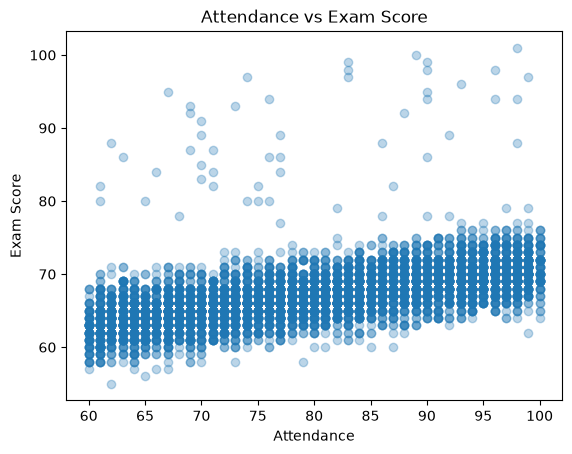

In [392]:
import matplotlib.pyplot as plt

plt.scatter(df["Attendance"], df["Exam_Score"], alpha=0.3)

plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")

plt.show()

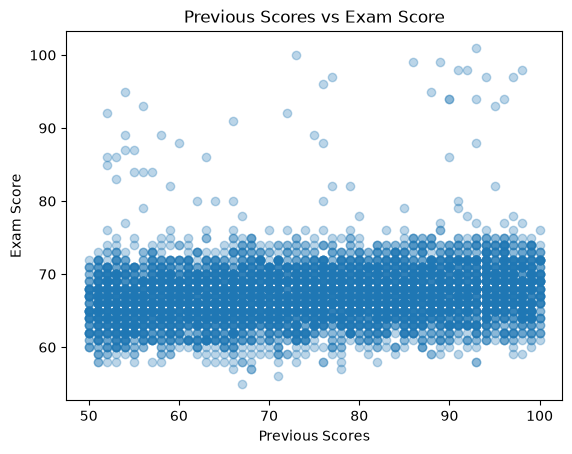

In [393]:
plt.scatter(df["Previous_Scores"], df["Exam_Score"], alpha=0.3)

plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.title("Previous Scores vs Exam Score")

plt.show()

In [394]:
model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ])

model.fit(X_train, y_train)

feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(coef_df)

                                       Feature  Coefficient  \
1                              num__Attendance     2.289388   
0                           num__Hours_Studied     1.755916   
10                cat__Access_to_Resources_Low    -1.055801   
9                cat__Access_to_Resources_High     1.044352   
6               cat__Parental_Involvement_High     1.024725   
7                cat__Parental_Involvement_Low    -0.978160   
3                         num__Previous_Scores     0.705885   
4                       num__Tutoring_Sessions     0.626668   
19                     cat__Family_Income_High     0.582123   
35  cat__Parental_Education_Level_Postgraduate     0.581993   
22                   cat__Teacher_Quality_High     0.545695   
28                cat__Peer_Influence_Negative    -0.537983   
14                  cat__Motivation_Level_High     0.531314   
20                      cat__Family_Income_Low    -0.525846   
15                   cat__Motivation_Level_Low    -0.51

In [395]:
from sklearn.impute import SimpleImputer

In [396]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [397]:
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

In [398]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [399]:
model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ])

In [400]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [401]:
model.predict(X_test)

array([64.52628302, 65.2651138 , 71.53126265, ..., 66.17193534,
       63.41615455, 71.76180129], shape=(1322,))

In [402]:
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions) ** 0.5)
print("R²:", r2_score(y_test, predictions))

MAE: 0.4523920089625977
RMSE: 1.8044445092722843
R²: 0.7696495724907311


In [403]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["Study_Tutoring_Interaction"] = (
    X_train["Hours_Studied"] *
    X_train["Tutoring_Sessions"]
)

X_test["Study_Tutoring_Interaction"] = (
    X_test["Hours_Studied"] *
    X_test["Tutoring_Sessions"]
)

In [404]:
numeric_features.append("Study_Tutoring_Interaction")
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 4. Rebuild model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# 5. FIT the new model
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Distance_from_Home','Gender','Study_Tutoring_Interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be au

In [405]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.4523089557284062
RMSE: 1.805236195089833
R²: 0.7694473992776139


In [406]:
numeric_features.remove("Study_Tutoring_Interaction")
X_train = X_train.drop(columns=["Study_Tutoring_Interaction"])
X_test = X_test.drop(columns=["Study_Tutoring_Interaction"])

In [407]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 4. Rebuild model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# 5. FIT the new model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [408]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["Motivation_Peer_Interaction"] = (
    X_train["Motivation_Level"].astype(str)
    + "_"
    + X_train["Peer_Influence"].astype(str)
)

X_test["Motivation_Peer_Interaction"] = (
    X_test["Motivation_Level"].astype(str)
    + "_"
    + X_test["Peer_Influence"].astype(str)
)

In [409]:
categorical_features.append(
    "Motivation_Peer_Interaction"
)

In [410]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [411]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [412]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Distance_from_Home','Gender','Motivation_Peer_Interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be a

In [413]:
predictions = model.predict(X_test)

In [414]:
print(
    "MAE:",
    mean_absolute_error(y_test, predictions)
)

print(
    "RMSE:",
    mean_squared_error(y_test, predictions) ** 0.5
)

print(
    "R²:",
    r2_score(y_test, predictions)
)

MAE: 0.45403212239991886
RMSE: 1.8036199197639984
R²: 0.769860054048507


In [415]:
X_train = X_train.drop(columns=["Motivation_Peer_Interaction"])
X_test = X_test.drop(columns=["Motivation_Peer_Interaction"])

categorical_features.remove("Motivation_Peer_Interaction")

In [416]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [417]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [418]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [419]:
predictions = model.predict(X_test)

analysis = X_test.copy()

analysis["Actual"] = y_test
analysis["Predicted"] = predictions
analysis["Residual"] = analysis["Actual"] - analysis["Predicted"]
analysis["Absolute_Error"] = analysis["Residual"].abs()

In [420]:
analysis.sort_values(
    "Residual",
    ascending=False
).head(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Actual,Predicted,Residual,Absolute_Error
217,19,70,Medium,Low,No,7,54,High,Yes,0,...,Positive,2,Yes,High School,Moderate,Male,89,60.989759,28.010241,28.010241
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,...,Positive,2,No,College,Moderate,Female,98,70.902730,27.097270,27.097270
2687,11,71,Low,Medium,Yes,8,55,Medium,Yes,1,...,Negative,3,No,College,Near,Female,87,60.105764,26.894236,26.894236
4531,26,69,High,High,No,7,95,Low,No,0,...,Negative,3,No,Postgraduate,Near,Female,93,67.554328,25.445672,25.445672
5966,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,...,Neutral,3,No,High School,Near,Male,97,73.039858,23.960142,23.960142
2513,18,86,High,Medium,No,8,60,Medium,Yes,2,...,Neutral,1,No,College,Near,Male,88,68.007096,19.992904,19.992904
5989,18,61,Medium,Low,Yes,6,91,High,Yes,3,...,Positive,3,No,College,Moderate,Female,80,64.929614,15.070386,15.070386
1002,20,69,High,Medium,No,7,63,Low,Yes,2,...,Negative,2,No,NaN,Moderate,Female,64,62.981410,1.018590,1.018590
6042,33,61,Low,Low,Yes,5,96,Medium,Yes,2,...,Negative,3,No,High School,Near,Male,67,66.035626,0.964374,0.964374
4878,16,98,Medium,Low,No,8,100,Low,Yes,2,...,Neutral,1,No,NaN,Near,Male,69,68.139523,0.860477,0.860477


In [421]:
analysis["Residual"].describe()

count    1322.000000
mean       -0.049164
std         1.804457
min        -1.570881
25%        -0.447550
50%        -0.182939
75%         0.096639
max        28.010241
Name: Residual, dtype: float64

In [422]:
high_residual = analysis[
    analysis["Residual"] > 10
]

print(high_residual.shape)

(7, 23)


In [423]:
high_residual

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Actual,Predicted,Residual,Absolute_Error
217,19,70,Medium,Low,No,7,54,High,Yes,0,...,Positive,2,Yes,High School,Moderate,Male,89,60.989759,28.010241,28.010241
2513,18,86,High,Medium,No,8,60,Medium,Yes,2,...,Neutral,1,No,College,Near,Male,88,68.007096,19.992904,19.992904
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,...,Positive,2,No,College,Moderate,Female,98,70.902730,27.097270,27.097270
5966,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,...,Neutral,3,No,High School,Near,Male,97,73.039858,23.960142,23.960142
5989,18,61,Medium,Low,Yes,6,91,High,Yes,3,...,Positive,3,No,College,Moderate,Female,80,64.929614,15.070386,15.070386
2687,11,71,Low,Medium,Yes,8,55,Medium,Yes,1,...,Negative,3,No,College,Near,Female,87,60.105764,26.894236,26.894236
4531,26,69,High,High,No,7,95,Low,No,0,...,Negative,3,No,Postgraduate,Near,Female,93,67.554328,25.445672,25.445672


In [424]:
numerical_comparison = pd.DataFrame({
    "High Residual": high_residual[numeric_features].mean(),
    "Other Students": analysis[
        analysis["Residual"] <= 10
    ][numeric_features].mean()
})

numerical_comparison["Difference"] = (
    numerical_comparison["High Residual"]
    - numerical_comparison["Other Students"]
)

numerical_comparison.sort_values(
    "Difference",
    ascending=False
)

,High Residual,Other Students,Difference
Hours_Studied,20.714286,20.004563,0.709723
Sleep_Hours,7.428571,7.045627,0.382944
Previous_Scores,74.714286,75.110266,-0.395980
Physical_Activity,2.428571,2.966540,-0.537968
Tutoring_Sessions,0.857143,1.473764,-0.616621
Attendance,78.000000,80.405323,-2.405323


In [425]:
categorical_comparison = []

other_students = analysis[
    analysis["Residual"] <= 10
]

for feature in categorical_features:
    high_dist = high_residual[feature].value_counts(normalize=True)
    other_dist = other_students[feature].value_counts(normalize=True)

    categories = set(high_dist.index) | set(other_dist.index)

    for category in categories:
        categorical_comparison.append({
            "Feature": feature,
            "Category": category,
            "High_Residual_%": high_dist.get(category, 0) * 100,
            "Other_%": other_dist.get(category, 0) * 100,
            "Difference": (
                high_dist.get(category, 0)
                - other_dist.get(category, 0)
            ) * 100
        })

categorical_comparison = pd.DataFrame(
    categorical_comparison
)

categorical_comparison.sort_values(
    "Difference",
    ascending=False
)

,Feature,Category,High_Residual_%,Other_%,Difference
27,Parental_Education_Level,College,57.142857,31.143740,25.999117
19,School_Type,Public,85.714286,69.125475,16.588810
13,Family_Income,Medium,57.142857,40.608365,16.534492
32,Gender,Female,57.142857,42.433460,14.709397
17,Teacher_Quality,High,42.857143,29.067078,13.790065
31,Distance_from_Home,Moderate,42.857143,29.715166,13.141977
5,Access_to_Resources,Low,28.571429,19.695817,8.875611
2,Parental_Involvement,Low,28.571429,20.076046,8.495383
23,Peer_Influence,Negative,28.571429,20.456274,8.115155
11,Internet_Access,No,14.285714,6.539924,7.745790


In [426]:
worst_under = analysis.nlargest(7, "Residual")
worst_over = analysis.nsmallest(7, "Residual")

In [427]:
worst_over[
    [
        "Actual",
        "Predicted",
        "Residual"
    ] + categorical_features
]

,Actual,Predicted,Residual,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
5725,65,66.570881,-1.570881,Medium,High,No,Medium,Yes,High,High,Public,Neutral,No,Postgraduate,NaN,Female
3543,57,58.119570,-1.119570,Low,Low,Yes,Low,Yes,Low,Medium,Public,Neutral,No,High School,Far,Female
3686,67,68.098534,-1.098534,Low,High,Yes,Medium,Yes,High,Low,Public,Positive,Yes,High School,Near,Male
5020,63,64.046471,-1.046471,High,Medium,Yes,Low,Yes,Low,Medium,Private,Neutral,Yes,College,Near,Female
4507,70,71.034731,-1.034731,Low,High,Yes,High,Yes,Medium,Medium,Public,Neutral,Yes,Postgraduate,Far,Male
5160,68,69.020828,-1.020828,High,High,Yes,Medium,Yes,Low,Medium,Public,Neutral,No,College,Near,Female
2647,62,63.009328,-1.009328,Medium,Medium,Yes,Medium,Yes,Low,High,Public,Neutral,No,High School,Far,Female


In [428]:
worst_under[
    [
        "Actual",
        "Predicted",
        "Residual"
    ] + categorical_features
]

,Actual,Predicted,Residual,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
217,89,60.989759,28.010241,Medium,Low,No,High,Yes,Medium,Medium,Public,Positive,Yes,High School,Moderate,Male
4192,98,70.902730,27.097270,Low,Medium,Yes,Medium,Yes,Medium,Medium,Public,Positive,No,College,Moderate,Female
2687,87,60.105764,26.894236,Low,Medium,Yes,Medium,Yes,Low,Medium,Public,Negative,No,College,Near,Female
4531,93,67.554328,25.445672,High,High,No,Low,No,Medium,Medium,Public,Negative,No,Postgraduate,Near,Female
5966,97,73.039858,23.960142,Medium,Medium,Yes,Medium,Yes,High,High,Public,Neutral,No,High School,Near,Male
2513,88,68.007096,19.992904,High,Medium,No,Medium,Yes,Low,High,Private,Neutral,No,College,Near,Male
5989,80,64.929614,15.070386,Medium,Low,Yes,High,Yes,Medium,High,Public,Positive,No,College,Moderate,Female


In [429]:
high_score = analysis[analysis["Actual"] >= 90]
other_students = analysis[analysis["Actual"] < 90]

print("High-score students:", len(high_score))
print("Other students:", len(other_students))


High-score students: 3
Other students: 1319


In [430]:
numerical_comparison = pd.DataFrame({
    "90+ Students": high_score[numeric_features].mean(),
    "Other Students": other_students[numeric_features].mean()
})

numerical_comparison["Difference"] = (
    numerical_comparison["90+ Students"]
    - numerical_comparison["Other Students"]
)

numerical_comparison.sort_values(
    "Difference",
    ascending=False
)

,90+ Students,Other Students,Difference
Previous_Scores,87.666667,75.079606,12.587061
Hours_Studied,26.333333,19.993935,6.339399
Attendance,86.000000,80.379833,5.620167
Sleep_Hours,7.666667,7.046247,0.620420
Physical_Activity,2.666667,2.964367,-0.297700
Tutoring_Sessions,0.000000,1.473844,-1.473844


In [431]:
high_score[
    [
        "Previous_Scores",
        "Hours_Studied",
        "Attendance",
        "Actual"
    ]
].corr()

,Previous_Scores,Hours_Studied,Attendance,Actual
Previous_Scores,1.000000,0.600284,-0.859071,-0.519861
Hours_Studied,0.600284,1.000000,-0.106311,0.371154
Attendance,-0.859071,-0.106311,1.000000,0.883852
Actual,-0.519861,0.371154,0.883852,1.000000


In [432]:
analysis[
    [
        "Previous_Scores",
        "Hours_Studied",
        "Attendance",
        "Actual"
    ]
].corr()

,Previous_Scores,Hours_Studied,Attendance,Actual
Previous_Scores,1.000000,0.073692,-0.053097,0.184116
Hours_Studied,0.073692,1.000000,-0.015508,0.483112
Attendance,-0.053097,-0.015508,1.000000,0.589962
Actual,0.184116,0.483112,0.589962,1.000000


In [433]:
high_score[
    [
        "Actual",
        "Predicted",
        "Residual",
        "Previous_Scores",
        "Hours_Studied",
        "Attendance"
    ]
].sort_values("Actual", ascending=False)

,Actual,Predicted,Residual,Previous_Scores,Hours_Studied,Attendance
4192,98,70.902730,27.097270,91,28,90
5966,97,73.039858,23.960142,77,25,99
4531,93,67.554328,25.445672,95,26,69


In [434]:
X_train.copy = X_train.copy()
X_test.copy = X_test.copy()

X_train["Previous_Attendance_Interaction"] = (
    X_train["Previous_Scores"] * X_train["Attendance"]
)

X_test["Previous_Attendance_Interaction"] = (
    X_test["Previous_Scores"] * X_test["Attendance"]
)


In [435]:
numeric_features.append("Previous_Attendance_Interaction")

In [442]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [443]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [444]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [439]:

predictions = model.predict(X_test)



In [440]:
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 0.4577324270950216
RMSE: 1.8053076663301701
R²: 0.7694291432659409


In [441]:
numeric_features.remove("Previous_Attendance_Interaction")
X_train = X_train.drop(columns=["Previous_Attendance_Interaction"])
X_test = X_test.drop(columns=["Previous_Attendance_Interaction"])

In [445]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [446]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [447]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be auto

In [448]:
from sklearn.ensemble import RandomForestRegressor

In [449]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [450]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf)
    ]
)

In [451]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [453]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

MAE: 1.079228441754917
RMSE: 2.155993159844207
R²: 0.671150854432788


In [454]:
depths = [2, 3, 5, 8, 10, 15, None]

results = []

for depth in depths:

    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    rf_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", rf)
        ]
    )

    rf_model.fit(X_train, y_train)

    predictions = rf_model.predict(X_test)

    results.append({
        "Depth": depth,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Depth,MAE,RMSE,R2
0,2.0,1.862634,2.786430,0.450714
1,3.0,1.685277,2.607118,0.519135
2,5.0,1.411582,2.360479,0.605813
3,8.0,1.228829,2.238283,0.645569
4,10.0,1.146352,2.185090,0.662215
5,15.0,1.084290,2.148955,0.673295
6,NaN,1.079228,2.155993,0.671151


In [455]:
from sklearn.ensemble import GradientBoostingRegressor

In [456]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

In [457]:
gbr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gbr)
    ]
)

In [458]:
gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

In [459]:
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R²:", r2_gbr)

MAE: 0.78879461907062
RMSE: 1.9351016136318802
R²: 0.7350831937919889


In [460]:
learning_rates = [0.01, 0.05, 0.1, 0.2]

results = []

for lr in learning_rates:

    gbr = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    gbr_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", gbr)
        ]
    )

    gbr_model.fit(X_train, y_train)

    predictions = gbr_model.predict(X_test)

    results.append({
        "Learning_Rate": lr,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    })

pd.DataFrame(results)

,Learning_Rate,MAE,RMSE,R2
0,0.01,1.865525,2.766192,0.458664
1,0.05,1.085247,2.108069,0.685608
2,0.10,0.788795,1.935102,0.735083
3,0.20,0.691976,1.915574,0.740403


In [462]:
n_estimators_list = [50, 100, 200, 300, 500]

results = []

for ne in n_estimators_list:

    gbr = GradientBoostingRegressor(
        n_estimators=ne,
        learning_rate=0.1,
        random_state=42
    )

    gbr_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", gbr)
        ]
    )

    gbr_model.fit(X_train, y_train)

    predictions = gbr_model.predict(X_test)

    results.append({
        "N_Estimators": ne,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    })

pd.DataFrame(results)

,N_Estimators,MAE,RMSE,R2
0,50,1.076775,2.097913,0.688630
1,100,0.788795,1.935102,0.735083
2,200,0.661173,1.887206,0.748035
3,300,0.659081,1.891674,0.746840
4,500,0.693842,1.934183,0.735335


In [463]:
depths = [1, 2, 3, 4, 5]

results = []

for d in depths:

    gbr = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=d,
        random_state=42
    )

    gbr_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", gbr)
        ]
    )

    gbr_model.fit(X_train, y_train)

    predictions = gbr_model.predict(X_test)

    results.append({
        "depth": d,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    })

pd.DataFrame(results)

,depth,MAE,RMSE,R2
0,1,0.914858,1.995158,0.718385
1,2,0.683058,1.881765,0.749486
2,3,0.661173,1.887206,0.748035
3,4,0.723040,1.944109,0.732611
4,5,0.832059,2.064246,0.698543


In [464]:
configs = [
    (0.05, 400),
    (0.10, 200),
    (0.20, 100)
]

results = []

for learning_rate, n_estimators in configs:

    gbr = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=2,
        random_state=42
    )

    gbr_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", gbr)
        ]
    )

    gbr_model.fit(X_train, y_train)

    predictions = gbr_model.predict(X_test)

    results.append({
        "Learning_Rate": learning_rate,
        "N_Estimators": n_estimators,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    })

pd.DataFrame(results)

,Learning_Rate,N_Estimators,MAE,RMSE,R2
0,0.05,400,0.684507,1.885217,0.748566
1,0.10,200,0.683058,1.881765,0.749486
2,0.20,100,0.692402,1.894779,0.746008


In [465]:
from sklearn.model_selection import cross_validate

In [466]:
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=5,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

In [468]:
cv_mae = -cv_results["test_MAE"]
cv_rmse = -cv_results["test_RMSE"]
cv_r2 = cv_results["test_R2"]

print("MAE:", cv_mae)
print("RMSE:", cv_rmse)
print("R²:", cv_r2)

print("\nMean:")
print("MAE:", cv_mae.mean())
print("RMSE:", cv_rmse.mean())
print("R²:", cv_r2.mean())

print("\nStandard deviation:")
print("MAE:", cv_mae.std())
print("RMSE:", cv_rmse.std())
print("R²:", cv_r2.std())

MAE: [0.45459405 0.43685747 0.50850265 0.52180711 0.6139745 ]
RMSE: [1.62577567 1.62464025 2.02256078 2.17933814 2.81024759]
R²: [0.79251866 0.81040724 0.74029085 0.70970706 0.56304289]

Mean:
MAE: 0.5071471541182355
RMSE: 2.052512485860656
R²: 0.7231933407844308

Standard deviation:
MAE: 0.06217925994501092
RMSE: 0.4373381519061106
R²: 0.08778910796532498


In [469]:
gbr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=2,
            random_state=42
        ))
    ]
)

In [470]:
cv_results_gbr = cross_validate(
    gbr_model,
    X_train,
    y_train,
    cv=5,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

cv_mae_gbr = -cv_results_gbr["test_MAE"]
cv_rmse_gbr = -cv_results_gbr["test_RMSE"]
cv_r2_gbr = cv_results_gbr["test_R2"]

print("MAE:", cv_mae_gbr)
print("RMSE:", cv_rmse_gbr)
print("R²:", cv_r2_gbr)

print("\nMean:")
print("MAE:", cv_mae_gbr.mean())
print("RMSE:", cv_rmse_gbr.mean())
print("R²:", cv_r2_gbr.mean())

print("\nStandard deviation:")
print("MAE:", cv_mae_gbr.std())
print("RMSE:", cv_rmse_gbr.std())
print("R²:", cv_r2_gbr.std())

MAE: [0.68206462 0.67561801 0.7235768  0.75403759 0.82840381]
RMSE: [1.71716758 1.7434381  2.08949665 2.27003688 2.857768  ]
R²: [0.76853616 0.78166649 0.72281645 0.6850417  0.54814033]

Mean:
MAE: 0.7327401660963415
RMSE: 2.135581441355996
R²: 0.7012402263998464

Standard deviation:
MAE: 0.05571361098464183
RMSE: 0.41727737738604326
R²: 0.0838625438126321


In [471]:
y_pred = model.predict(X_test)

residuals = y_test - y_pred

In [472]:
residual_df = X_test.copy()

residual_df["Actual"] = y_test
residual_df["Predicted"] = y_pred
residual_df["Residual"] = residuals
residual_df["Absolute_Error"] = abs(residuals)

residual_df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Actual,Predicted,Residual,Absolute_Error
743,20,71,Medium,Low,No,7,87,High,Yes,1,...,Negative,5,No,High School,Near,Male,65,64.526283,0.473717,0.473717
5551,22,71,Medium,Low,Yes,7,98,Low,Yes,2,...,Neutral,2,No,High School,Moderate,Female,65,65.265114,-0.265114,0.265114
3442,21,91,High,Medium,Yes,6,53,High,Yes,1,...,Positive,3,No,Postgraduate,Near,Female,71,71.531263,-0.531263,0.531263
6571,12,91,Medium,Low,Yes,8,81,Low,Yes,0,...,Positive,4,No,High School,Moderate,Male,64,64.277481,-0.277481,0.277481
4204,21,63,Low,High,Yes,8,95,Medium,Yes,2,...,Neutral,5,No,High School,Near,Male,66,66.521653,-0.521653,0.521653


In [473]:
largest_errors = residual_df.sort_values(
    "Absolute_Error",
    ascending=False
)

largest_errors.head(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Actual,Predicted,Residual,Absolute_Error
217,19,70,Medium,Low,No,7,54,High,Yes,0,...,Positive,2,Yes,High School,Moderate,Male,89,60.989759,28.010241,28.010241
4192,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,...,Positive,2,No,College,Moderate,Female,98,70.902730,27.097270,27.097270
2687,11,71,Low,Medium,Yes,8,55,Medium,Yes,1,...,Negative,3,No,College,Near,Female,87,60.105764,26.894236,26.894236
4531,26,69,High,High,No,7,95,Low,No,0,...,Negative,3,No,Postgraduate,Near,Female,93,67.554328,25.445672,25.445672
5966,25,99,Medium,Medium,Yes,7,77,Medium,Yes,0,...,Neutral,3,No,High School,Near,Male,97,73.039858,23.960142,23.960142
2513,18,86,High,Medium,No,8,60,Medium,Yes,2,...,Neutral,1,No,College,Near,Male,88,68.007096,19.992904,19.992904
5989,18,61,Medium,Low,Yes,6,91,High,Yes,3,...,Positive,3,No,College,Moderate,Female,80,64.929614,15.070386,15.070386
5725,13,73,Medium,High,No,8,93,Medium,Yes,0,...,Neutral,3,No,Postgraduate,NaN,Female,65,66.570881,-1.570881,1.570881
3543,14,67,Low,Low,Yes,7,66,Low,Yes,0,...,Neutral,4,No,High School,Far,Female,57,58.119570,-1.119570,1.119570
3686,35,68,Low,High,Yes,5,64,Medium,Yes,0,...,Positive,4,Yes,High School,Near,Male,67,68.098534,-1.098534,1.098534


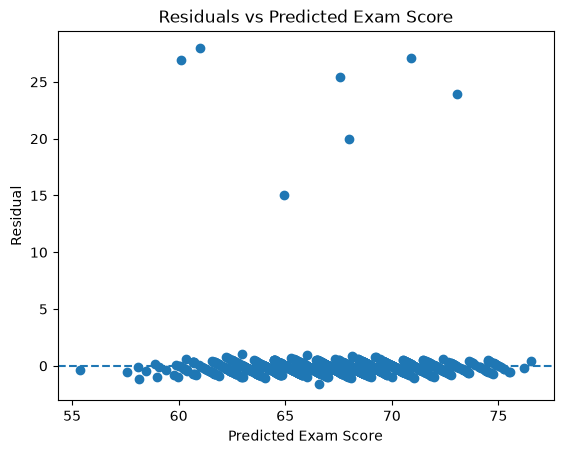

In [474]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Exam Score")

plt.show()

In [475]:
np.corrcoef(y_pred, residuals)[0, 1]

np.float64(-0.010693404507668869)

In [476]:
print("Mean residual:", residuals.mean())
print("Median residual:", np.median(residuals))
print("Residual std:", residuals.std())

Mean residual: -0.04916383846569471
Median residual: -0.1829389832238455
Residual std: 1.8044572283147968


**Linear Regression is the preferred model for this dataset.** It achieved the strongest predictive performance among the tested models and maintained its advantage across cross-validation. More complex tree-based approaches, including tuned Gradient Boosting, failed to improve generalisation. Residual analysis showed little overall bias and no obvious systematic relationship between predictions and residuals. The remaining large individual errors likely reflect variation that cannot be explained by the available features, highlighting a limitation of the dataset rather than an obvious need for a more complex model.